In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
X, y = make_classification(
    
    n_samples=3000,
    
    n_features=10,
    
    n_informative=8,
    
    n_redundant=2,
    
    n_classes=2,
    
    random_state=42
)

print(X.shape)

(3000, 10)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    
    y,
    
    test_size=0.20,
    
    random_state=42,
    
    stratify=y
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [5]:
train_accuracy = []

test_accuracy = []

k_values = range(1,26)

for k in k_values:
    
    model = KNeighborsClassifier(
        
        n_neighbors=k
    )
    
    model.fit(X_train,y_train)
    
    train_pred = model.predict(X_train)
    
    test_pred = model.predict(X_test)
    
    train_accuracy.append(
        
        accuracy_score(
            y_train,
            train_pred
        )
    )
    
    test_accuracy.append(
        
        accuracy_score(
            y_test,
            test_pred
        )
    )

In [6]:
results = pd.DataFrame({
    
    "K":list(k_values),
    
    "Train Accuracy":train_accuracy,
    
    "Test Accuracy":test_accuracy
})

results.head()

,K,Train Accuracy,Test Accuracy
0,1,1.000000,0.896667
1,2,0.939167,0.875000
2,3,0.962917,0.906667
3,4,0.938750,0.901667
4,5,0.949583,0.913333


In [7]:
best_index = np.argmax(test_accuracy)

best_k = list(k_values)[best_index]

best_score = test_accuracy[best_index]

print("Best K :",best_k)

print("Best Accuracy :",best_score)

Best K : 5
Best Accuracy : 0.9133333333333333


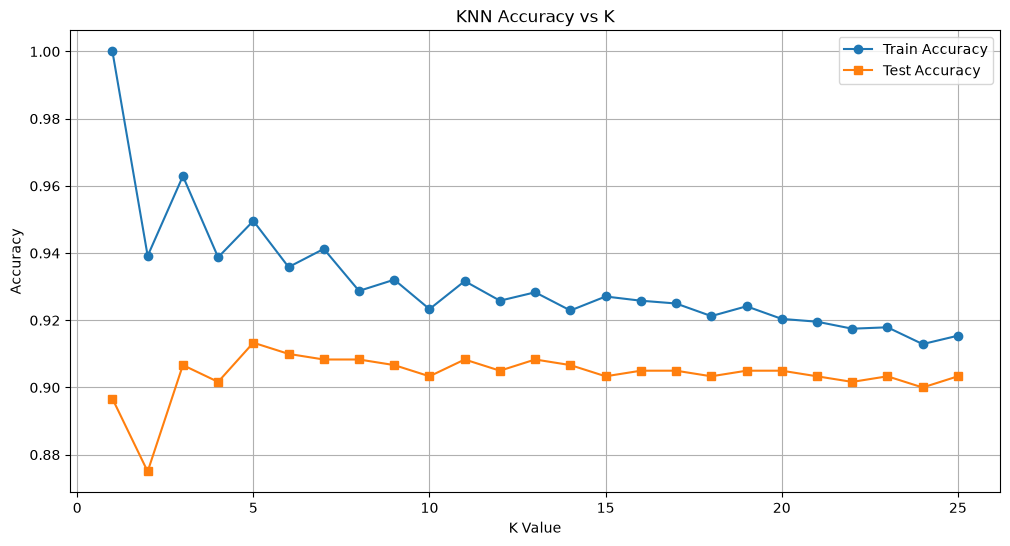

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    k_values,
    train_accuracy,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    k_values,
    test_accuracy,
    marker="s",
    label="Test Accuracy"
)

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("KNN Accuracy vs K")

plt.legend()

plt.grid()

plt.show()

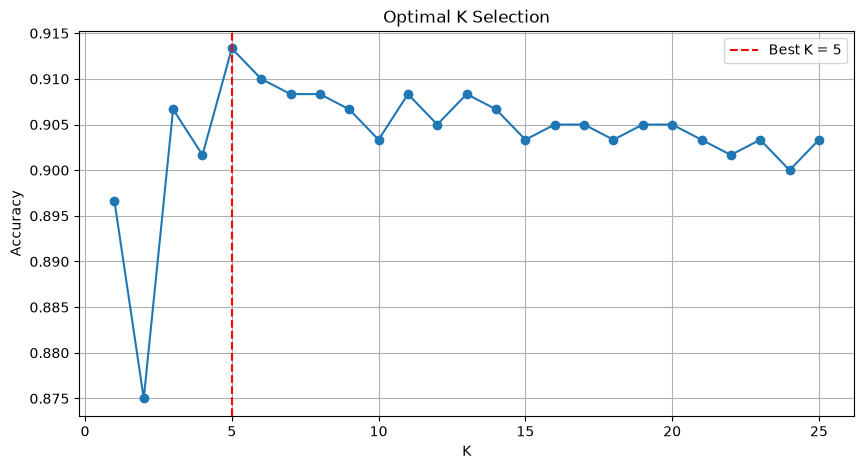

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    k_values,
    test_accuracy,
    marker="o"
)

plt.axvline(
    best_k,
    color="red",
    linestyle="--",
    label=f"Best K = {best_k}"
)

plt.legend()

plt.title("Optimal K Selection")

plt.xlabel("K")

plt.ylabel("Accuracy")

plt.grid()

plt.show()

In [10]:
final_model = KNeighborsClassifier(
    
    n_neighbors=best_k
)

final_model.fit(
    
    X_train,
    
    y_train
)

prediction = final_model.predict(
    
    X_test
)

In [11]:
print(
    accuracy_score(
        y_test,
        prediction
    )
)

0.9133333333333333
